<a href="https://colab.research.google.com/github/isaacadebayo/Predictive_Analytics_and_NLP/blob/main/Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

In [2]:
drive.mount('/content/drive')
data = pd.read_csv('/content/drive/MyDrive/Walmart.csv')

Mounted at /content/drive


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
data.shape

(6435, 8)

In [6]:
data.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


### Feature Engineering

In [7]:
data['Affordability_per_sale_CPI' ]= data['CPI'] / data['Weekly_Sales']
#data['Affordability_per_unemployment' ]= data['Unemployment'] / data['Weekly_Sales']

In [8]:
data

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Affordability_per_sale_CPI
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106,0.000128
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106,0.000129
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106,0.000131
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106,0.000150
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106,0.000136
...,...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684,0.000269
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667,0.000262
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667,0.000262
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667,0.000268


For Affordability per sale, weekly sale goes up as CPI goes up per month section due to metric tracking inflation and purchasing power of currency. Therefore Affordability per sale goes down

### EDA

<function matplotlib.pyplot.show(close=None, block=None)>

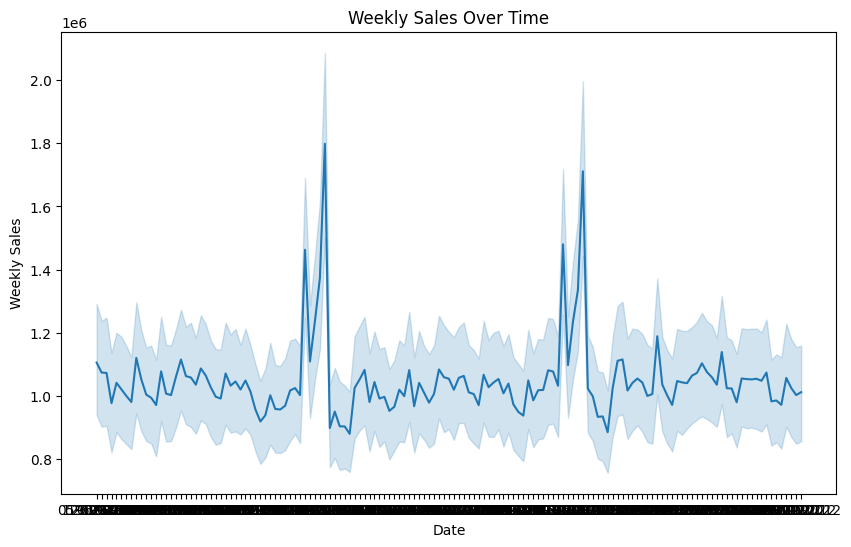

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='Weekly_Sales', data=data)
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

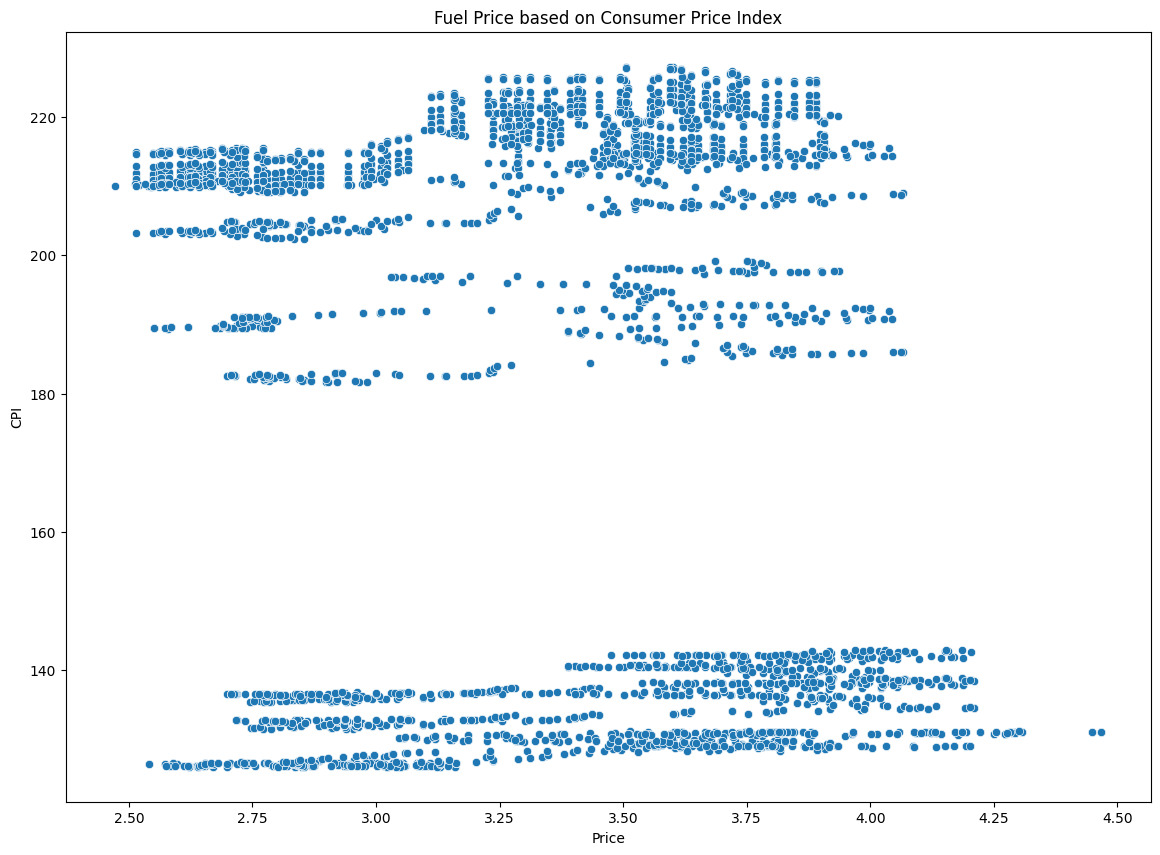

In [10]:
plt.figure(figsize=(14, 10))
sns.scatterplot(x='Fuel_Price', y='CPI', data=data)
plt.title('Fuel Price based on Consumer Price Index')
plt.xlabel('Price')
plt.ylabel('CPI')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

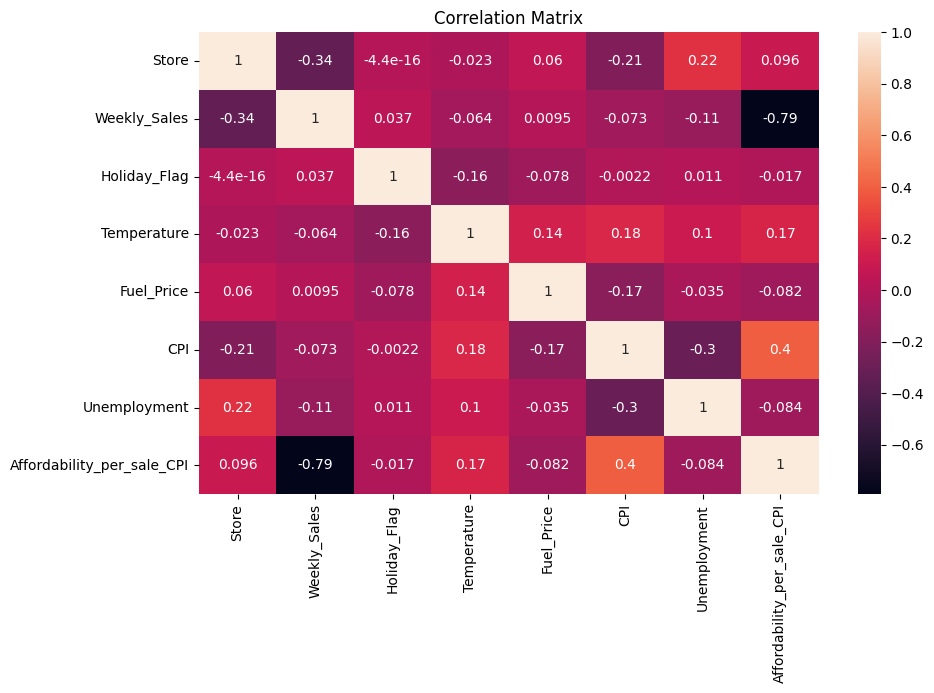

In [11]:
data2 = data.copy()
data3 = data2.drop('Date', axis=1)
#corr = data.select_dtypes(exclude='Date').corr()

plt.figure(figsize=(10,6))
sns.heatmap(data3.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show

#data3.info()

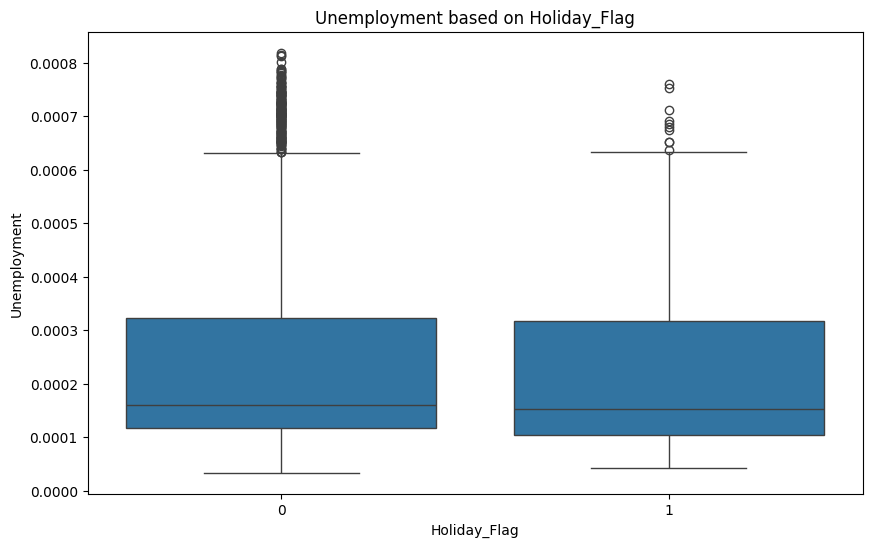

In [12]:
plt.figure(figsize=(10,6))
sns.boxplot(y='Affordability_per_sale_CPI', x='Holiday_Flag', data=data)
plt.xlabel('Holiday_Flag')
plt.ylabel('Unemployment')
plt.title('Unemployment based on Holiday_Flag')
plt.show()

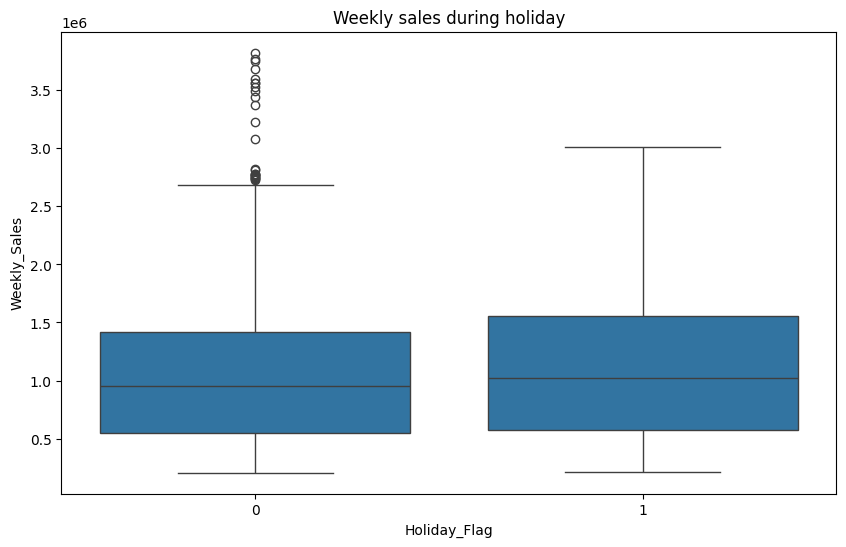

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(y='Weekly_Sales', x='Holiday_Flag', data=data)
plt.ylabel('Weekly_Sales')
plt.xlabel('Holiday_Flag')
plt.title('Weekly sales during holiday')
plt.show()

### Dropping target variable

In [14]:
X_data = data3.drop(columns=['Weekly_Sales'])
y = data3['Weekly_Sales']

if you scale before dropping you introduce data leakage

### Split featurees to X_train and X_test

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data, y,
                                                    test_size=0.2)

# Scaling

Scale only X_train

,count,mean,std,min,25%,50%,75%,max
Store,5148.0,-9.523591e-17,1.000097,-1.702229,-0.854513,-0.006796,0.840920,1.688636
Holiday_Flag,5148.0,-3.036507e-17,1.000097,-0.271327,-0.271327,-0.271327,-0.271327,3.685589
Temperature,5148.0,-2.208369e-16,1.000097,-2.974059,-0.719638,0.109121,0.776119,2.126831
Fuel_Price,5148.0,-7.712039e-16,1.000097,-1.940480,-0.930995,0.196227,0.820342,2.411426
CPI,5148.0,-3.588600e-16,1.000097,-1.150538,-1.008839,0.285537,1.048991,1.421778
Unemployment,5148.0,-1.828806e-16,1.000097,-2.167796,-0.590512,-0.067016,0.314230,3.288897
Affordability_per_sale_CPI,5148.0,2.084148e-16,1.000097,-1.250702,-0.726551,-0.452664,0.576578,3.743405


,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Affordability_per_sale_CPI
Store,1.000000,-0.002792,-0.024127,0.044709,-0.208438,0.216345,0.088296
Holiday_Flag,-0.002792,1.000000,-0.143948,-0.075023,-0.001008,0.008856,-0.018953
Temperature,-0.024127,-0.143948,1.000000,0.145356,0.174038,0.103438,0.158778
Fuel_Price,0.044709,-0.075023,0.145356,1.000000,-0.163041,-0.032699,-0.088675
CPI,-0.208438,-0.001008,0.174038,-0.163041,1.000000,-0.310827,0.399246
Unemployment,0.216345,0.008856,0.103438,-0.032699,-0.310827,1.000000,-0.089223
Affordability_per_sale_CPI,0.088296,-0.018953,0.158778,-0.088675,0.399246,-0.089223,1.000000


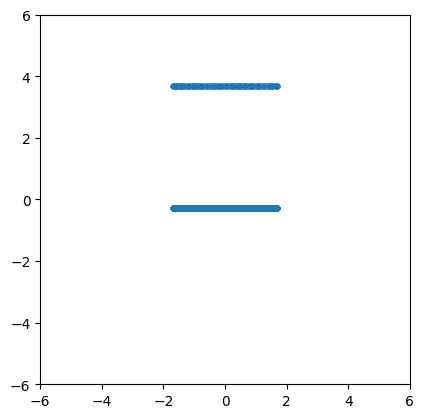

In [16]:

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X1_data = scaler.fit_transform(X_train)

df_X1_data = pd.DataFrame(X1_data, columns=X_train.columns)
display(df_X1_data.describe().T)
display(df_X1_data.corr())

plt.plot( X1_data[:,0], X1_data[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

### Principal Component Analysis

PCA on X_train

In [17]:
from sklearn.decomposition import PCA

pca = PCA(n_components=7)

X_train_pca = pd.DataFrame(
    pca.fit_transform(X1_data)
)

### Scaling and PCA for test data

,count,mean,std,min,25%,50%,75%,max
Store,5148.0,-9.523591e-17,1.000097,-1.702229,-0.854513,-0.006796,0.840920,1.688636
Holiday_Flag,5148.0,-3.036507e-17,1.000097,-0.271327,-0.271327,-0.271327,-0.271327,3.685589
Temperature,5148.0,-2.208369e-16,1.000097,-2.974059,-0.719638,0.109121,0.776119,2.126831
Fuel_Price,5148.0,-7.712039e-16,1.000097,-1.940480,-0.930995,0.196227,0.820342,2.411426
CPI,5148.0,-3.588600e-16,1.000097,-1.150538,-1.008839,0.285537,1.048991,1.421778
Unemployment,5148.0,-1.828806e-16,1.000097,-2.167796,-0.590512,-0.067016,0.314230,3.288897
Affordability_per_sale_CPI,5148.0,2.084148e-16,1.000097,-1.250702,-0.726551,-0.452664,0.576578,3.743405


,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Affordability_per_sale_CPI
Store,1.000000,-0.002792,-0.024127,0.044709,-0.208438,0.216345,0.088296
Holiday_Flag,-0.002792,1.000000,-0.143948,-0.075023,-0.001008,0.008856,-0.018953
Temperature,-0.024127,-0.143948,1.000000,0.145356,0.174038,0.103438,0.158778
Fuel_Price,0.044709,-0.075023,0.145356,1.000000,-0.163041,-0.032699,-0.088675
CPI,-0.208438,-0.001008,0.174038,-0.163041,1.000000,-0.310827,0.399246
Unemployment,0.216345,0.008856,0.103438,-0.032699,-0.310827,1.000000,-0.089223
Affordability_per_sale_CPI,0.088296,-0.018953,0.158778,-0.088675,0.399246,-0.089223,1.000000


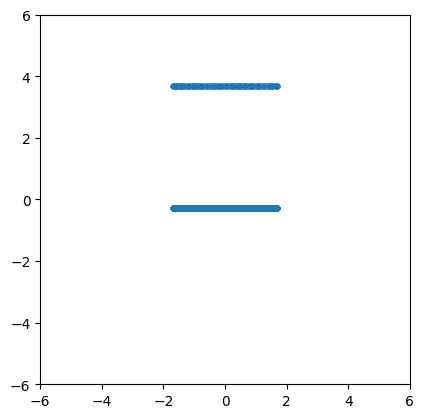

In [18]:

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X1_test_data = scaler.fit_transform(X_test)

df_X1_test_data = pd.DataFrame(X1_data, columns=X_test.columns)
display(df_X1_test_data.describe().T)
display(df_X1_test_data.corr())

plt.plot( X1_data[:,0], X1_data[:,1], '.' )
plt.xlim(-6,6)
plt.ylim(-6,6)
plt.gca().set_aspect('equal')

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=7)

X_test_pca = pd.DataFrame(
    pca.fit_transform(X1_test_data)
)

## Models

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=1, weights='uniform'),
    KNeighborsRegressor(n_neighbors=10, weights='uniform'),
    KNeighborsRegressor(n_neighbors=100, weights='uniform'),
    DecisionTreeRegressor(max_depth=2),
    DecisionTreeRegressor(max_depth=5),
    DecisionTreeRegressor(max_depth=10),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=100, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
]

In [21]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True)

X_train_pca.columns = X_train_pca.columns.astype(str) # Convert column names to strings

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, X_train_pca, y_train, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()
# end

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.279539,0.012276,0.265676,0.273439,0.278866,0.280916,0.298801



KNeighborsRegressor(n_neighbors=1)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.071761,0.00418,0.06778,0.069769,0.071189,0.071268,0.078797



KNeighborsRegressor(n_neighbors=10)


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.246962,0.004253,0.241489,0.246422,0.246636,0.24682,0.253441



RandomForestRegressor(max_depth=10)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.097941,0.004323,0.092938,0.09563,0.096181,0.102208,0.102747



GradientBoostingRegressor(max_depth=2)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.201055,0.007001,0.193919,0.196967,0.197413,0.206956,0.210018


#Grid Search CV

In [22]:
from sklearn.model_selection import GridSearchCV

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "DecisionTreeRegressor": (
        DecisionTreeRegressor(),
        {
            "max_depth": [2, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "LinearRegression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
        }
    ),

  }

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True)

X_train_pca.columns = X_train_pca.columns.astype(str) # Convert column names to strings

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_train_pca, y_train)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...
Performing GridSearchCV for DecisionTreeRegressor...
Performing GridSearchCV for LinearRegression...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.06374782980000562),
  'Best Params': {'n_neighbors': 5, 'weights': 'distance'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.09872972618667744),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 2,
   'min_samples_split': 2,
   'n_estimators': 100}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.08178279316043065),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 5,
   'min_samples_leaf': 5,
   'n_estimators': 200}},
 {'Model': 'DecisionTreeRegressor',
  'Best Score': np.float64(-0.13025187516227824),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 5}},
 {'Model': 'LinearRegression',
  'Best Score': np.float64(-0.2796190820728048),
  'Best Params': {'fit_intercept': True}}]

## Parismony

In [26]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(X_train_pca, y_train)

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances = importances[:10]

features_rf = importances.index

X_pars = X_train[ features_rf ]
importances

,0
Temperature,0.286288
Unemployment,0.166995
Affordability_per_sale_CPI,0.160174
Store,0.141987
Fuel_Price,0.103458
Holiday_Flag,0.089769
CPI,0.051328


## VIF

In [28]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 175.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 18.0 MB/s eta 0:00:00


In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_pars_with_const = sm.add_constant(X_pars)

vif = pd.Series(
    [variance_inflation_factor(X_pars_with_const.values, i) for i in range(X_pars_with_const.shape[1])],
    index=X_pars_with_const.columns
).sort_values(ascending=False)

vif[:10]

,0
const,133.549371
CPI,1.454614
Affordability_per_sale_CPI,1.249952
Unemployment,1.190463
Temperature,1.138478
Store,1.115969
Fuel_Price,1.083443
Holiday_Flag,1.025414


In [30]:
# Copy dataset to avoid modifying the original
X_vif = X_pars.copy()
while True:
  X_vif_with_const = sm.add_constant(X_vif)

  # Compute VIF for all features
  vif_series = pd.Series(
  [variance_inflation_factor(X_vif_with_const.values, i) for i in range(X_vif_with_const.shape[1])],
  index=X_vif_with_const.columns
    )
  #Exclude constant term
  vif_series = vif_series.drop('const', errors='ignore')
  highest_vif_feature = vif_series.idxmax()
  # Break the loop if all features have VIF ≤ 10
  if vif_series.loc[highest_vif_feature] <= 10:  # Checking the first feature after 'const'
    break

  # Drop the feature with the highest VIF
  X_vif = X_vif.drop(columns=[highest_vif_feature])

  print(f"Dropped: {highest_vif_feature} (VIF={vif_series.loc[highest_vif_feature]:.2f})")
  # end


vif_series[:25]

,0
Temperature,1.138478
Unemployment,1.190463
Affordability_per_sale_CPI,1.249952
Store,1.115969
Fuel_Price,1.083443
Holiday_Flag,1.025414
CPI,1.454614


In [35]:
from sklearn.model_selection import GridSearchCV

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "DecisionTreeRegressor": (
        DecisionTreeRegressor(),
        {
            "max_depth": [2, 3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "LinearRegression": (
        LinearRegression(),
        {
            "fit_intercept": [True, False],
        }
    ),

  }

# Define cross-validation strategy
kf = KFold(n_splits=5, shuffle=True)

X_train.columns = X_train.columns.astype(str) # Convert column names to strings

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...
Performing GridSearchCV for DecisionTreeRegressor...
Performing GridSearchCV for LinearRegression...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.18353468415287452),
  'Best Params': {'n_neighbors': 1, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.00816209397430423),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 1,
   'min_samples_split': 2,
   'n_estimators': 100}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.007120479033038388),
  'Best Params': {'learning_rate': 0.1,
   'max_depth': 5,
   'min_samples_leaf': 2,
   'n_estimators': 200}},
 {'Model': 'DecisionTreeRegressor',
  'Best Score': np.float64(-0.013092901014438257),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 2,
   'min_samples_split': 2}},
 {'Model': 'LinearRegression',
  'Best Score': np.float64(-0.2799342085959368),
  'Best Params': {'fit_intercept': True}}]

### Prediction on X_test

In [38]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

y_pred = grid_search.predict(X_test)
print('MAE Score is: ', mean_absolute_percentage_error(y_test, y_pred))
print('R Score is:', r2_score(y_test, y_pred))

MAE Score is:  0.29855074109785124
R Score is: 0.7530955758305162
